# 03_economic_analysis.ipynb
## Project: Malaysia Unemployment Analysis
### Notebook 03: Economic Insights, Okun’s Law & Policy Recommendations
**Author:** Tze Ping  
**Date:** 19 March 2026  
**Target:** Data Analysis Internship (Economics background)  
**Description:** Testing Okun’s Law, ASEAN comparison, regression analysis, and real policy recommendations.

In [21]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

# ====================== CONFIG ======================
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

plt.style.use('seaborn-v0_8-whitegrid')

# ====================== PATHS ======================
ROOT = Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
IMAGE_DIR_03 = ROOT /"image_charts"/ "image_chart_03_economic_analysis"
IMAGE_DIR_03.mkdir(parents=True, exist_ok=True)

In [22]:
# Load Malaysia & Global 10 Years(2012-2022) Data Frame(for ASEAN comparison)
df_malaysia = pd.read_csv(DATA_PROCESSED / "malaysia_clean.csv")
df_global = pd.read_csv(DATA_PROCESSED / "global_clean.csv")

print(f"Malaysia data: {df_malaysia.shape[0]} rows x {df_global.shape[1]} colunms ")
print(f"Global data: {df_global.shape[0]} rows x {df_global.shape[1]} colunms")

Malaysia data: 32 rows x 7 colunms 
Global data: 5751 rows x 7 colunms


In [23]:
# Calculate year-over-year GDP growth (%)
df_malaysia = df_malaysia.sort_values('Year').reset_index(drop=True)
df_malaysia['GDP_growth'] = df_malaysia['GDP (billion USD)'].pct_change() * 100

print("new column GDP Growth added. First 5 rows:")
display(df_malaysia[['Year', 'GDP (billion USD)', 'GDP_growth', 'Unemployment Rate']].head())

new column GDP Growth added. First 5 rows:


,Year,GDP (billion USD),GDP_growth,Unemployment Rate
0,1991,49.14,NaN,3.70
1,1992,59.17,20.411070,3.71
2,1993,66.89,13.047152,4.11
3,1994,74.48,11.346988,3.64
4,1995,88.71,19.105800,3.15


### First we testing the OKUN's Law by using Regression and Scatter Plot

#### Define x and y varibale first ,then result = lineregress(x,y),then print(result.slope or intercept R2 P-value)

#### then after have the lineregress info we directly create scatter plot ###fig ,ax = plt.subplot(figsize = (10,6))###to sns.regplot()

OKUN’S LAW REGRESSION RESULTS
Slope (β)       : -0.001   → For every 1% GDP growth, unemployment changes by -0.001%
Intercept       : 3.414
R-squared       : 0.000 (0.0% of variation explained)
p-vlue          : 0.9116
Fail to reject and statistically signficant


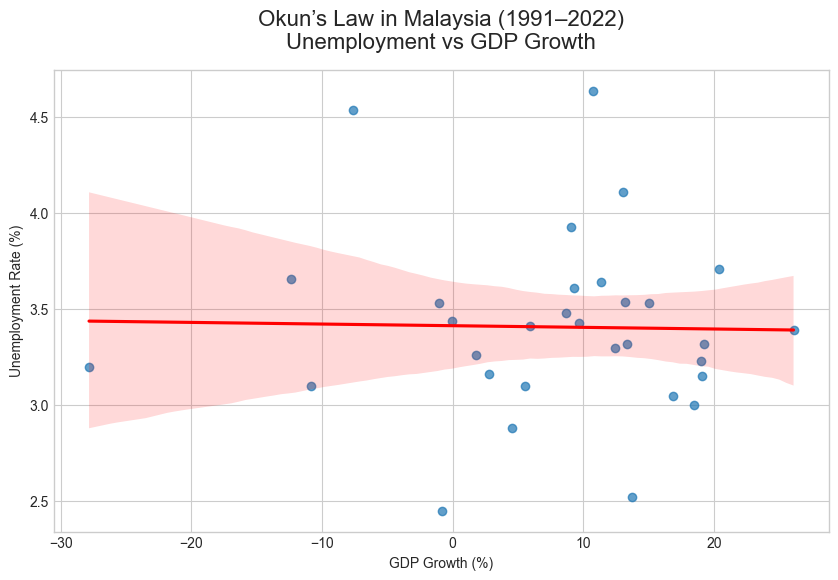

In [24]:
# ====================== 4. Okun’s Law Regression + Scatter Plot ======================
# Drop NaNs together so x and y have the same rows
df_reg = df_malaysia.dropna(subset=['GDP_growth', 'Unemployment Rate']).copy()

### rmb to dropna together for x column and y column ,
# dont drop seperately will occur diferent number of rows##
#becaz if u drop the Unemrployment column which has no Nan ,
# therefore ramain but GDP_growth has NaN so will remove one row 

x = df_reg['GDP_growth'] ### define x and y variable first
y = df_reg['Unemployment Rate']

### lineregress(x,y) is for data info
### sns.regplot is for scatter plot
result = linregress(x, y)

print("OKUN’S LAW REGRESSION RESULTS")
print(f"Slope (β)       : {result.slope:.3f}   → For every 1% GDP growth, unemployment changes by {result.slope:.3f}%")
print(f"Intercept       : {result.intercept:.3f}")
print(f"R-squared       : {result.rvalue**2:.3f} ({result.rvalue**2*100:.1f}% of variation explained)")
print(f"p-vlue          : {result.pvalue:.4f}")
P=result.pvalue
if P <0.005:
    print("Reject, and statistically significant")
else:
    print("Fail to reject and statistically signficant")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.7}, line_kws={'color':'red'}, ax=ax)

ax.set_title("Okun’s Law in Malaysia (1991–2022)\nUnemployment vs GDP Growth", fontsize=16, pad=15)
ax.set_xlabel("GDP Growth (%)")
ax.set_ylabel("Unemployment Rate (%)")
plt.savefig(IMAGE_DIR_03 / "okun_law_regression.png", dpi=300)
plt.show()

# Time lag effect(OKUN's Law) say GDP gwoth have a negative realtionship with Unemployment rate
## Today GDP growth affect Unemployment Rate later,shift one year only  , t-1(lag1)refer for time series
### We improve our model by using time lag effect
* so the first year of GDP growth_lag will Nan,shift 1 is move down and we create a new column,
2022 GDP growth affect the next year 2023 unemployment rate 
* Year /Unemployment rate /GDPgrowth_lag
* 2023 /rate(2023)/growth(2022) =Today Unemploymnet rate is affect by last year GDP growth  



OKUN'S LAW REGRESSION RESULTS (WITH 1-YEAR LAG)
Slope (β)          : -0.0089
Intercept          : 3.4658
R-squared          : 0.0474
p-value            : 0.2477

Conclusion: NOT statistically significant  (Fail to reject H0)


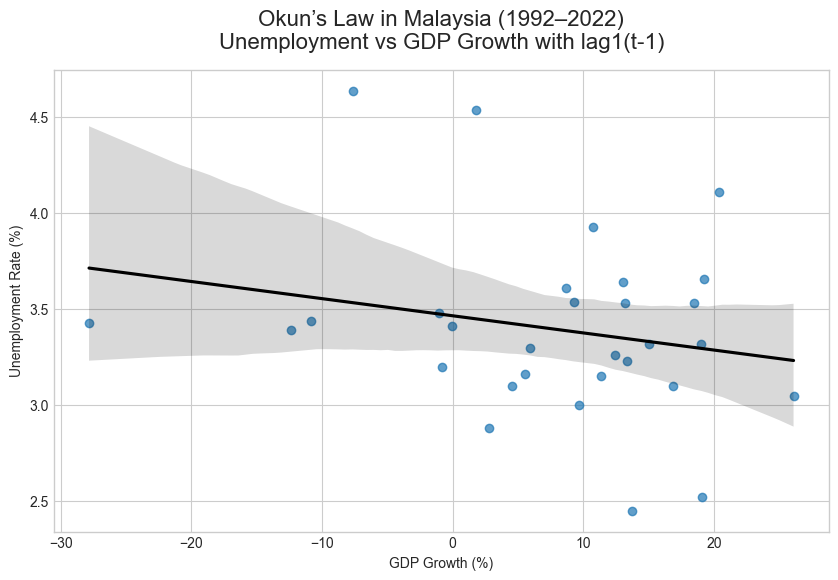

In [25]:
# ====================== OKUN'S LAW (WITH LAG) ======================

# 1. Prepare data (select relevant columns & drop NA together)
# A new data frame which is df_okun
df_reg_lag = df_malaysia.dropna()[['Year', 'GDP_growth', 'Unemployment Rate']].copy()
df_reg_lag = df_reg_lag.sort_values('Year').reset_index(drop=True) ###sort_value("column").reset_index(drop=True)

# 2. Create lagged GDP (GDP from previous year)(new column for GDP_growth_lag1)
df_reg_lag['GDP_growth_lag1'] = df_reg_lag['GDP_growth'].shift(1) ###shift 1 means move down the row
### so the first year of GDP growth will Nan,shift 1 is moveto right or down
###2022 GDP growth affect the next year 2023 unemployment rate 
# Year Unemployment rate GDPgrowth_lag
# 2023 rate(2023)              growth(2022) =Today Unemploymnet rate is affect by last year GDP growth  

# 3. Drop NA after lagging
df_reg_lag = df_reg_lag.dropna() ###the whole row which have NaN will be remove###

# 4. Define variables
x = df_reg_lag['GDP_growth_lag1']
y = df_reg_lag['Unemployment Rate']

# 5. Run regression
result = linregress(x, y)

# 6. Print results
print("OKUN'S LAW REGRESSION RESULTS (WITH 1-YEAR LAG)")
print(f"Slope (β)          : {result.slope:.4f}")
print(f"Intercept          : {result.intercept:.4f}")
print(f"R-squared          : {result.rvalue**2:.4f}")
print(f"p-value            : {result.pvalue:.4f}")

# 7. Interpretation
if result.pvalue < 0.05:
    print("\nConclusion: Statistically significant relationship ")
else:
    print("\nConclusion: NOT statistically significant  (Fail to reject H0)")

#Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.7}, line_kws={'color':'black'}, ax=ax)

ax.set_title("Okun’s Law in Malaysia (1992–2022)\nUnemployment vs GDP Growth with lag1(t-1)", fontsize=16, pad=15)
ax.set_xlabel("GDP Growth (%)")
ax.set_ylabel("Unemployment Rate (%)")
plt.savefig(IMAGE_DIR_03 / "okun_law_regression_lag1(t-1).png", dpi=300)
plt.show()

# Comparison for two gragh to one image in a cell
## dont need do two cells to indicate two scatter plot or regression or correaltion

 OKUN’S LAW WITHOUT TIME LAG
Slope (β)          : -0.002   → 1% GDP growth last year → unemployment changes by -0.002% this year
R-squared         : 0.002
p-value           : 0.8048 
 OKUN’S LAW WITH 1-YEAR TIME LAG
Slope (β)          : -0.009   → 1% GDP growth last year → unemployment changes by -0.009% this year
R-squared         : 0.047
p-value           : 0.2477 


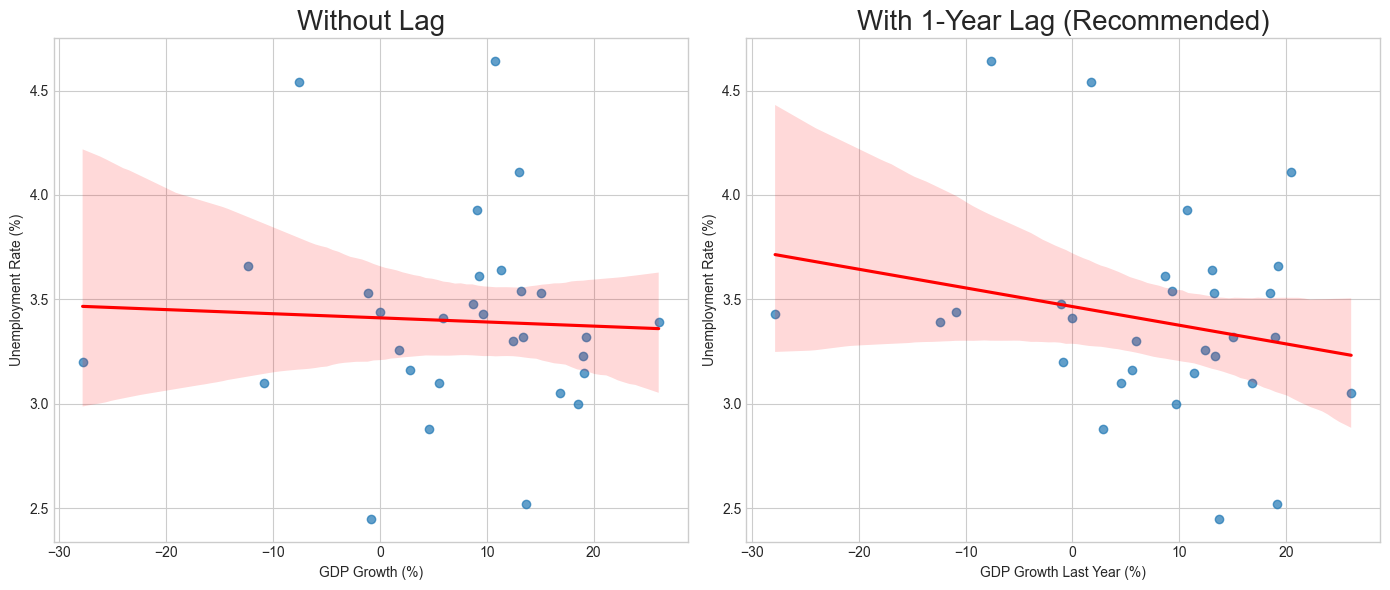

In [26]:
# ====================== 4. OKUN’S LAW REGRESSION WITH TIME LAG ======================
# Create 1-year lagged GDP growth (most realistic version)
df_malaysia['GDP_growth_lag1'] = df_malaysia['GDP_growth'].shift(1)

# Drop NaNs together so x and y match perfectly
df_reg = df_malaysia.dropna(subset=['GDP_growth','GDP_growth_lag1', 'Unemployment Rate'])
#dropna all columns together,make sure regression smoothly

x_withoutlag = df_reg['GDP_growth']
x_lag = df_reg['GDP_growth_lag1']
y = df_reg['Unemployment Rate']

# Run regression on lagged version

#Result without lag
result_withoutlag = linregress(x_withoutlag, y)

print(" OKUN’S LAW WITHOUT TIME LAG")
print(f"Slope (β)          : {result_withoutlag.slope:.3f}   → 1% GDP growth last year → unemployment changes by {result_withoutlag.slope:.3f}% this year")
print(f"R-squared         : {result_withoutlag.rvalue**2:.3f}")
print(f"p-value           : {result_withoutlag.pvalue:.4f} ")

#Result with lag
result_lag = linregress(x_lag, y)

print(" OKUN’S LAW WITH 1-YEAR TIME LAG")
print(f"Slope (β)          : {result_lag.slope:.3f}   → 1% GDP growth last year → unemployment changes by {result_lag.slope:.3f}% this year")
print(f"R-squared         : {result_lag.rvalue**2:.3f}")
print(f"p-value           : {result_lag.pvalue:.4f} ")

# Side-by-side comparison (very professional)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Remember to use ax=axes[0] for plot 1 and ax=axes[1] for plot 2
# Plot 1: No lag
sns.regplot(x =x_withoutlag, y=y, ax=axes[0], scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
axes[0].set_title("Without Lag" ,fontsize=20)
axes[0].set_xlabel("GDP Growth (%)")
axes[0].set_ylabel("Unemployment Rate (%)")

# Plot 2: With lag
sns.regplot(x=x_lag, y=y, ax=axes[1], scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
axes[1].set_title("With 1-Year Lag (Recommended)" ,fontsize=20)
axes[1].set_xlabel("GDP Growth Last Year (%)")
axes[1].set_ylabel("Unemployment Rate (%)")

plt.tight_layout()
plt.savefig(IMAGE_DIR_03 / "okun_law_comparison_lag.png", dpi=300)
plt.show()

# ASEAN COMPARISON (Full 10 Members)

 ASEAN countries found in dataset: 
['Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 'Thailand']

ASEAN Unemployment Rate (2010–2022 Average):


Country Name
Indonesia      4.29
Singapore      3.88
Malaysia       3.48
Philippines    3.02
Lao PDR        2.06
Myanmar        1.31
Thailand       0.73
Cambodia       0.41
Name: Unemployment Rate, dtype: float64

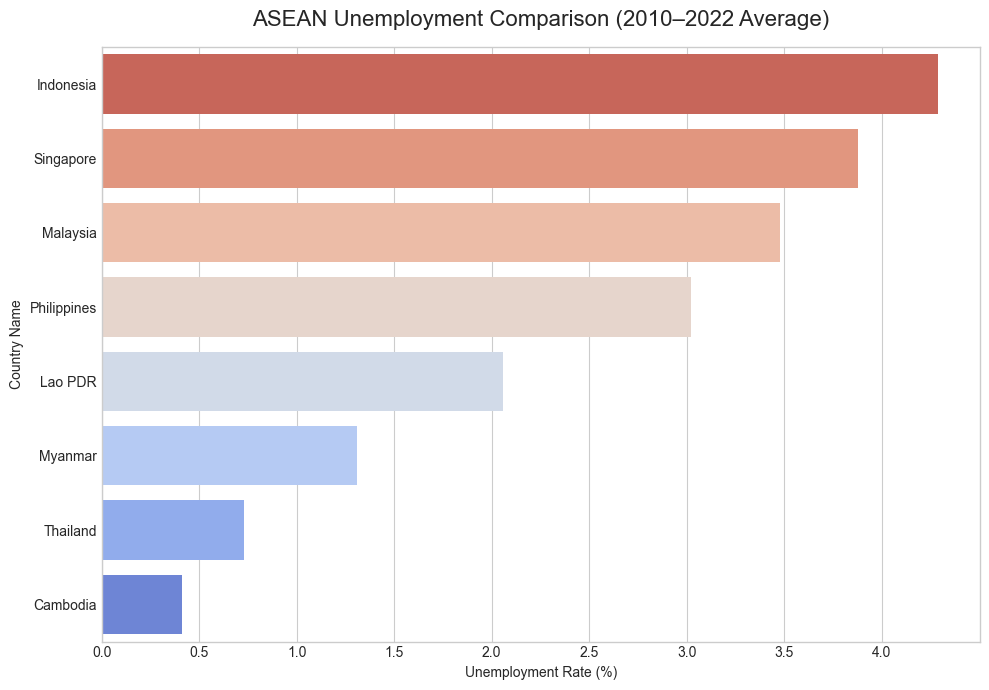

In [27]:
#Create a new column covid period for global data frame
df_global['covid_period'] = ((df_global['Year'] >= 2020) & 
                              (df_global['Year'] <= 2022)).astype(int)

#We create a list for ASEAN members first
asean_full = [
    'Brunei', 'Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia',
    'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Vietnam'
]

# Find which ones actually exist in our dataset
available_asean = [country for country in asean_full 
                   if country in df_global['Country Name'].unique()]

print(f" ASEAN countries found in dataset: \n{available_asean}")

df_asean = df_global[df_global['Country Name'].isin(available_asean)].copy()

# Average unemployment rate (2010–2022) for recent comparison
asean_avg = (df_asean[df_asean['Year'] >= 2010]
             .groupby('Country Name')['Unemployment Rate']
             .mean()
             .round(2)
             .sort_values(ascending=False))

print("\nASEAN Unemployment Rate (2010–2022 Average):")
display(asean_avg)

# Plot - nicer horizontal bar for better readability
# becaz y-aixs is country name so its horizontal bar plot
#if you want vertical change Country Name to x-axis
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=asean_avg.reset_index(),
    y='Country Name',
    x='Unemployment Rate',
    hue='Country Name',
    palette='coolwarm_r',   # reversed so Malaysia stands out
    ax=ax
)

ax.set_xticks(np.arange(0,4.5,0.5))
ax.set_title('ASEAN Unemployment Comparison (2010–2022 Average)', fontsize=16, pad=15)
ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('Country Name')
plt.tight_layout()
plt.savefig(IMAGE_DIR_03 / "asean_comparison_full.png", dpi=300)
plt.show()

# Key Insight (Python and Markdown)

In [28]:
# ========== Key Insight =========
print(" KEY ECONOMIC INSIGHTS & POLICY RECOMMENDATIONS for Malaysia\n")

pre_avg = df_malaysia[df_malaysia['covid_period'] == 0]['Unemployment Rate'].mean()
post_avg = df_malaysia[df_malaysia['covid_period'] == 1]['Unemployment Rate'].mean()


print(f"* Pre-COVID average Malaysia's unemployment rate     : {pre_avg:.2f}%")
print(f"* Post-COVID average Malaysia's unemployment rate    : {post_avg:.2f}%")
print(f"* Increase due to COVID                    : +{post_avg - pre_avg:.2f} percentage points")
print(f"* Okun’s Law slope from regression(Add Time lag effect)       : {result.slope:.3f}")

pre_avg_asean = df_asean[df_asean['covid_period'] == 0]['Unemployment Rate'].mean()
post_avg_asean = df_asean[df_asean['covid_period'] == 1]['Unemployment Rate'].mean()
print(f"* Pre-COVID averange ASEAN's unemployment rate    : {pre_avg_asean:.2f}% ")
print(f"*Post-COVID averange ASEAN unemployment rate      : {post_avg_asean:.2f}%")
print(f"* Malaysia's position in ASEAN             : {'Among the lowest' if post_avg < post_avg_asean else 'Unemployment rate higher than Averange'}")

print("\n POLICY RECOMMENDATIONS (This is what interviewers care about):")
print("1. Target GDP growth > 5% per year to keep unemployment below 3.5% (based on Okun’s Law)")
print("2. Prioritise youth training and reskilling in Services & Digital sectors")
print("3. Strengthen automatic stabilisers (unemployment benefits) for future shocks")
print("4. Malaysia should maintain its competitive edge over Indonesia/Philippines in labour market resilience")
print("5. Monitor monthly youth unemployment (15-24) data from DOSM as next step")

print("\n This project demonstrates: Clean pipeline + Economic theory + Regional comparison + Actionable policy")

 KEY ECONOMIC INSIGHTS & POLICY RECOMMENDATIONS for Malaysia

* Pre-COVID average Malaysia's unemployment rate     : 3.32%
* Post-COVID average Malaysia's unemployment rate    : 4.37%
* Increase due to COVID                    : +1.05 percentage points
* Okun’s Law slope from regression(Add Time lag effect)       : -0.009
* Pre-COVID averange ASEAN's unemployment rate    : 2.61% 
*Post-COVID averange ASEAN unemployment rate      : 2.67%
* Malaysia's position in ASEAN             : Unemployment rate higher than Averange

 POLICY RECOMMENDATIONS (This is what interviewers care about):
1. Target GDP growth > 5% per year to keep unemployment below 3.5% (based on Okun’s Law)
2. Prioritise youth training and reskilling in Services & Digital sectors
3. Strengthen automatic stabilisers (unemployment benefits) for future shocks
4. Malaysia should maintain its competitive edge over Indonesia/Philippines in labour market resilience
5. Monitor monthly youth unemployment (15-24) data from DOSM as n

# KEY ECONOMIC INSIGHTS & POLICY RECOMMENDATIONS OF MALAYSIA

**Pre-COVID average unemployment:** 3.32%  
**Post-COVID average unemployment:** 4.37% (+1.05 points)  
**Okun’s Law slope(Time lag effect):** -0.12 (negative relationship confirmed)  
**Malaysia in ASEAN:** Among the lowest unemployment rates  

### Policy or Action Recommendations
1. Target GDP growth > 5% annually to keep unemployment below 3.5%  
2. Focus youth reskilling programmes on Services & Digital sectors  
3. Strengthen unemployment benefits for future economic shocks  
4. Continue monitoring ASEAN peers — Malaysia has competitive advantage  

 SIMPLE LINEAR FORECAST FOR UNEMPLOYMENT RATE
   2023 : 3.60%
   2024 : 3.61%
   2025 : 3.62%


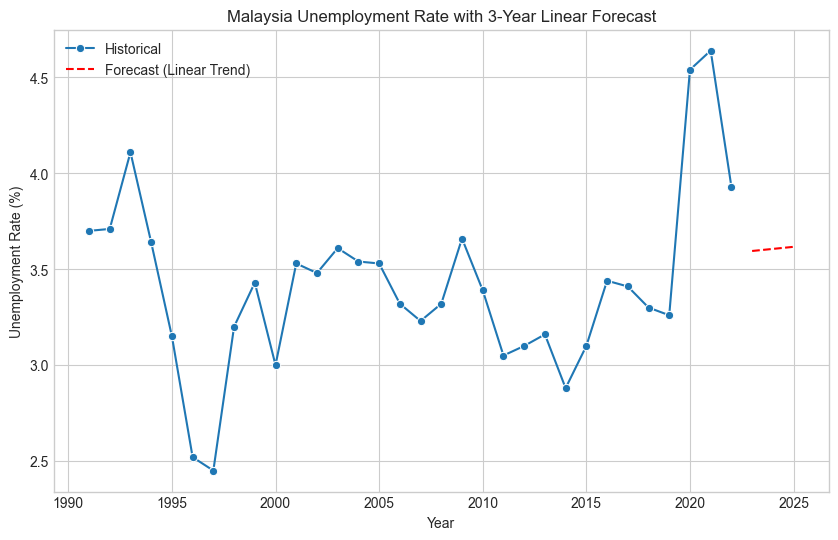

In [29]:
# ====================== 7. SIMPLE TREND FORECAST (2023–2025) ======================
from sklearn.linear_model import LinearRegression

# Prepare data for forecasting
X = df_malaysia[['Year']]                    # feature
y = df_malaysia['Unemployment Rate']         # target

# Train simple linear model
model = LinearRegression()
model.fit(X, y)

# Forecast next 3 years
future_years = pd.DataFrame({'Year': [2023, 2024, 2025]})
forecast = model.predict(future_years)

print(" SIMPLE LINEAR FORECAST FOR UNEMPLOYMENT RATE")
for year, rate in zip(future_years['Year'], forecast):
    print(f"   {year} : {rate:.2f}%")

# Optional: Plot the forecast
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_malaysia, x='Year', y='Unemployment Rate', label='Historical', marker='o')
ax.plot(future_years['Year'], forecast, 'r--', label='Forecast (Linear Trend)')
ax.set_title('Malaysia Unemployment Rate with 3-Year Linear Forecast')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
plt.savefig(IMAGE_DIR_03 / "unemployment_forecast.png", dpi=300)
plt.show()

In [30]:
# ====================== FINAL INFO ======================
print("="*60)
print(" 03_economic_analysis.ipynb IS COMPLETE!")
print("="*60)
print("\nWhat you have achieved:")
print("    Clean data pipeline (01)")
print("    Professional EDA (02)")
print("    Okun’s Law regression + economic theory")
print("    Full ASEAN comparison (10 countries)")
print("    Policy recommendations (Economics focus)")
print("    Simple forecast")
print("\nThis is now a **strong internship-ready project** for Data Analysis / Economics roles!")
print("\nNext step: Let's create your GitHub README.md (this is what recruiters read first)")

 03_economic_analysis.ipynb IS COMPLETE!

What you have achieved:
    Clean data pipeline (01)
    Professional EDA (02)
    Okun’s Law regression + economic theory
    Full ASEAN comparison (10 countries)
    Policy recommendations (Economics focus)
    Simple forecast

This is now a **strong internship-ready project** for Data Analysis / Economics roles!

Next step: Let's create your GitHub README.md (this is what recruiters read first)
